#### Importing Required Libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Setting style for plots
plt.style.use('ggplot')
sns.set_palette('viridis')

#### Loading the Data

In [ ]:
# Loading my dataset
df = pd.read_csv('dataset/data.csv', sep=';')

# Showing the first 5 rows
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


#### Exploring Data Basics

In [14]:
# Checking the dimensions of the dataset and null values
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

In [4]:
# Looking at summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [5]:
# Checking for any null values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 Series([], dtype: int64)


#### Doing Exploratory Data Analysis (EDA)

#### Target Variable Distribution

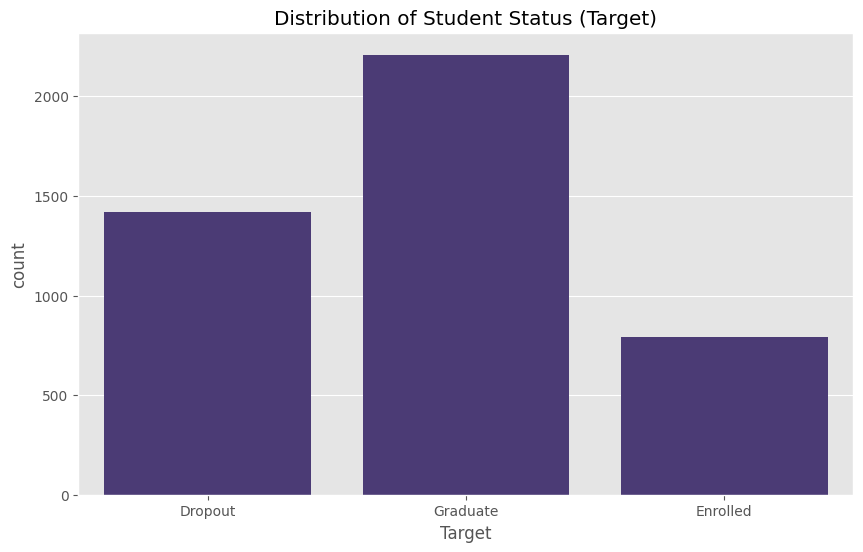

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Target')
plt.title('Distribution of Student Status (Target)')
plt.show()

#### Age at Enrollment vs Target

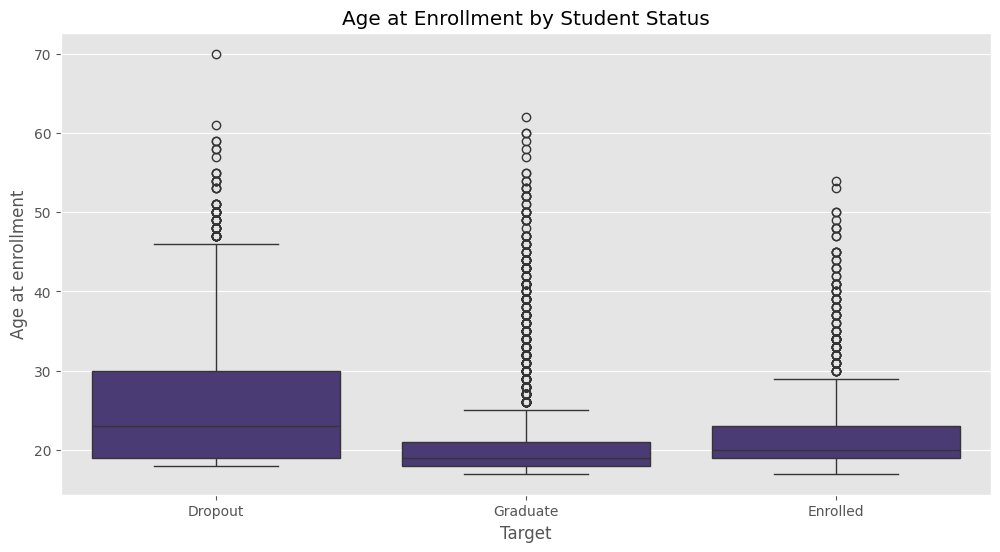

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Age at enrollment')
plt.title('Age at Enrollment by Student Status')
plt.show()

#### Academic Performance (1st Sem vs 2nd Sem Grade)

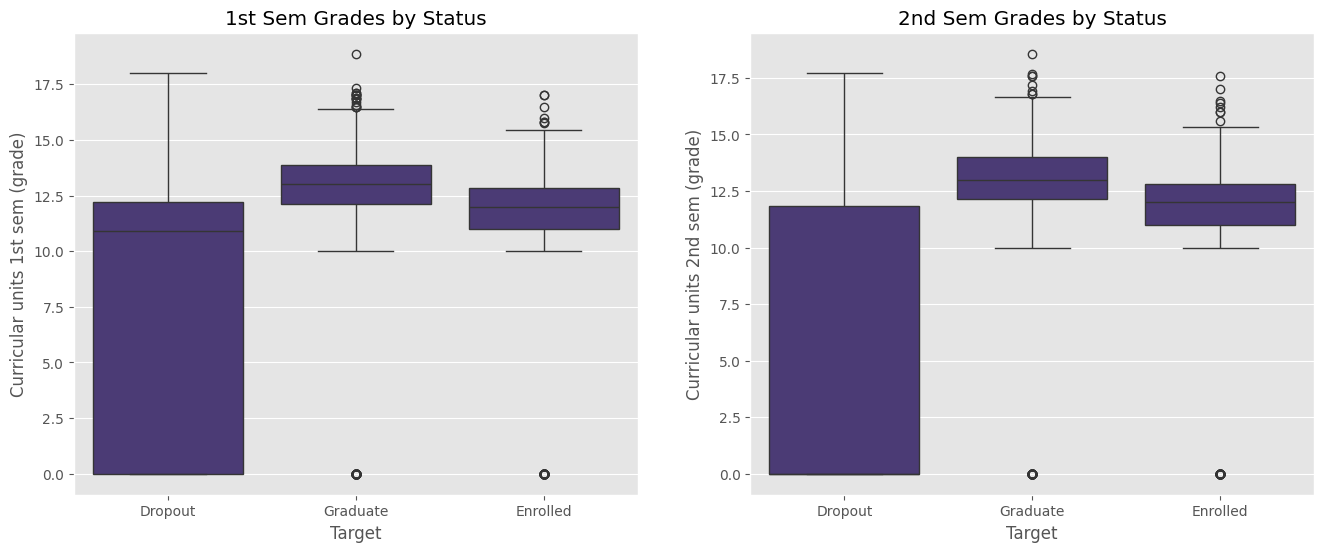

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)', ax=ax[0])
ax[0].set_title('1st Sem Grades by Status')

sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', ax=ax[1])
ax[1].set_title('2nd Sem Grades by Status')

plt.show()

#### Gender and Scholarship Status

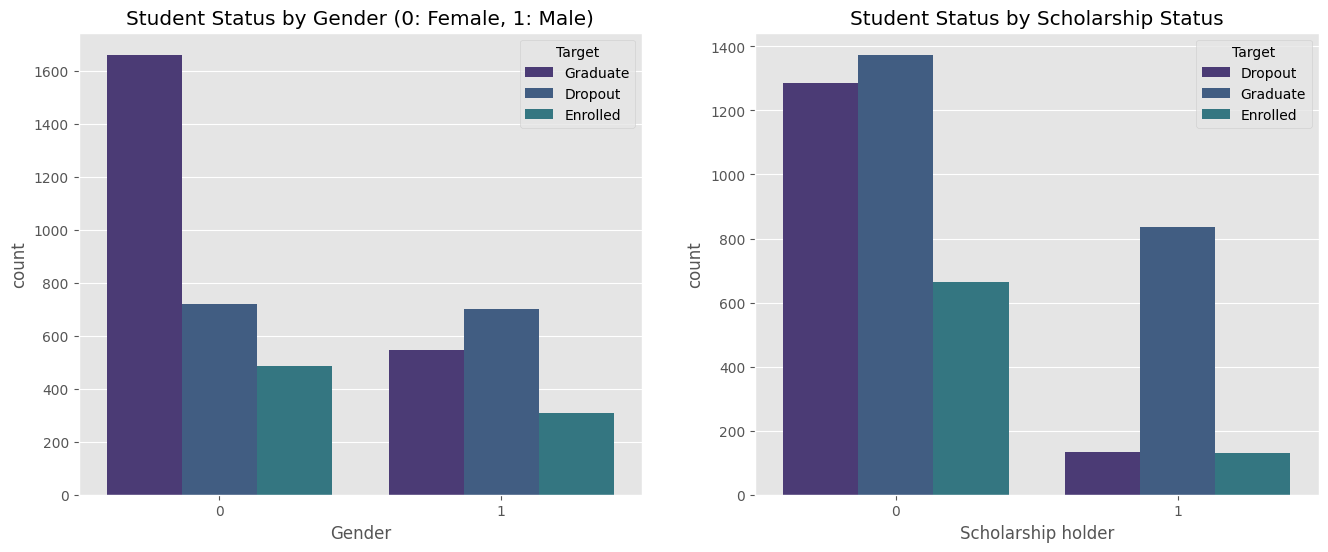

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Gender', hue='Target', ax=ax[0])
ax[0].set_title('Student Status by Gender (0: Female, 1: Male)')

sns.countplot(data=df, x='Scholarship holder', hue='Target', ax=ax[1])
ax[1].set_title('Student Status by Scholarship Status')

plt.show()

#### Correlation Heatmap

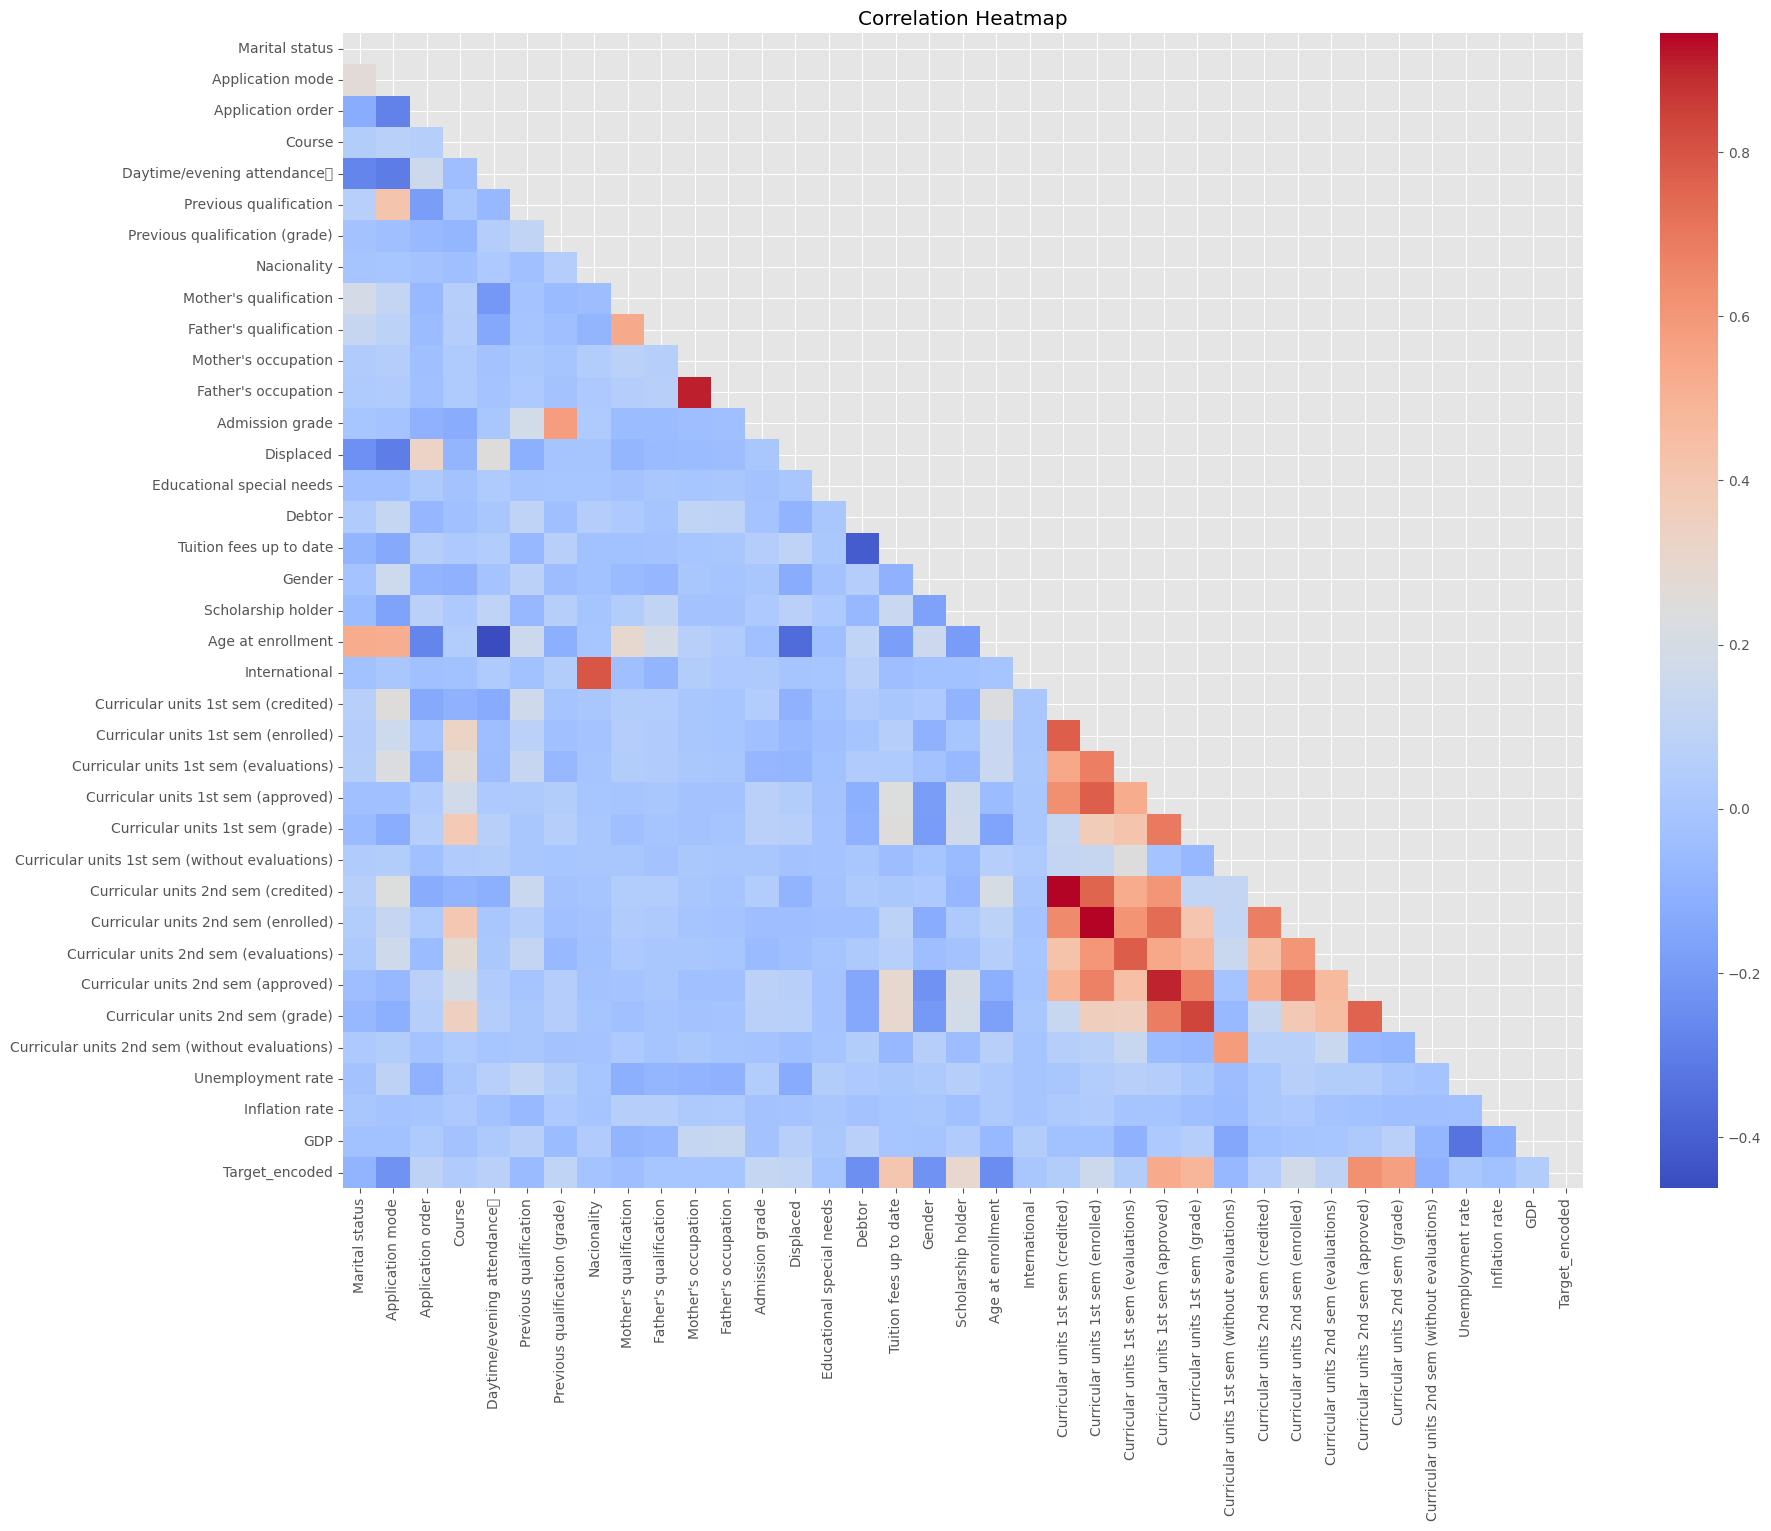

In [10]:
# Encoding target variable for correlation calculation
df_corr = df.copy()
df_corr['Target_encoded'] = df_corr['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

plt.figure(figsize=(20, 15))
mask = np.triu(np.ones_like(df_corr.select_dtypes(include=[np.number]).corr(), dtype=bool))
sns.heatmap(df_corr.select_dtypes(include=[np.number]).corr(), mask=mask, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### Preprocessing the Data

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Preparing features (X) and target (y)
X = df.drop('Target', axis=1)
y = df['Target']

# Encoding the categorical target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Detected Classes:", le.classes_)

# Scaling our numerical features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Detected Classes: ['Dropout' 'Enrolled' 'Graduate']
Training set shape: (3539, 36)
Testing set shape: (885, 36)


#### Building our Baseline Model

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initializing the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model on our training data
rf_model.fit(X_train, y_train)

# Making predictions on the set test set
y_pred = rf_model.predict(X_test)

print("Baseline Model Training Complete.")

Baseline Model Training Complete.


#### Evaluating our Model

In [15]:
# Printing the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}")

Baseline Accuracy: 0.7695



Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.57      0.38      0.45       159
    Graduate       0.79      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



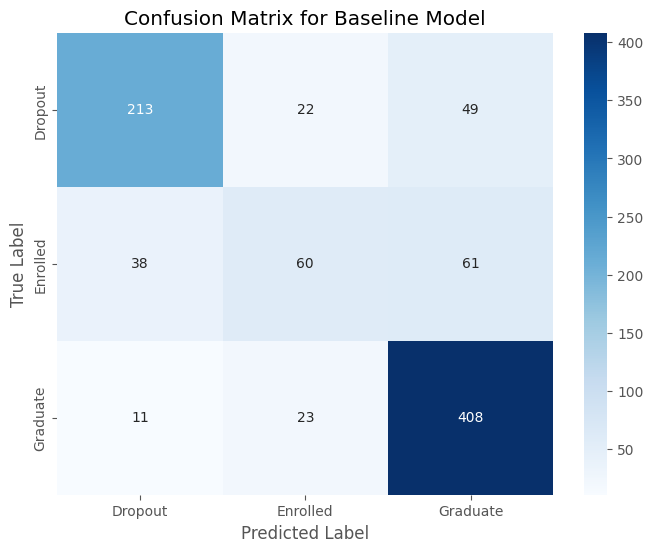

In [16]:
# Showing the detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()